# Demodulación de AM por Submuestreo (Bandpass Sampling)

Se pretende mostrar cómo utilizar el teorema de Nyquist para demodular una señal y traer la información a la banda base. 

El teorema tradicional nos dice que para no perder información debemos muestrear al menos al doble de la frecuencia máxima de la señal. Sin embargo, para señales pasabanda como la Amplitud Modulada (AM), el ancho de banda real de la información ($B$) es muy pequeño en comparación con la alta frecuencia de la portadora ($f_c$). 

**¿Por qué funciona demodular solo muestreando?**
Al muestrear una señal analógica, su espectro de frecuencias crea "réplicas" o alias en múltiplos enteros de la frecuencia de muestreo ($f_s$). Si provocamos un aliasing de forma intencional eligiendo una frecuencia de muestreo que cumpla estas dos condiciones:
1. Que respete a Nyquist respecto al mensaje original ($f_s \ge 2B$).
2. Que la portadora sea un múltiplo entero de la frecuencia de muestreo ($f_c = k \cdot f_s$).

Logramos que una de esas réplicas caiga **exactamente en 0 Hz (banda base)**. Al coincidir los instantes de muestreo exactamente con los picos de la portadora, la señal de alta frecuencia se "desvanece" en el muestreo discreto, y los puntos resultantes trazan únicamente la envolvente original. El propio proceso de muestreo actúa como un mezclador/demodulador perfecto.

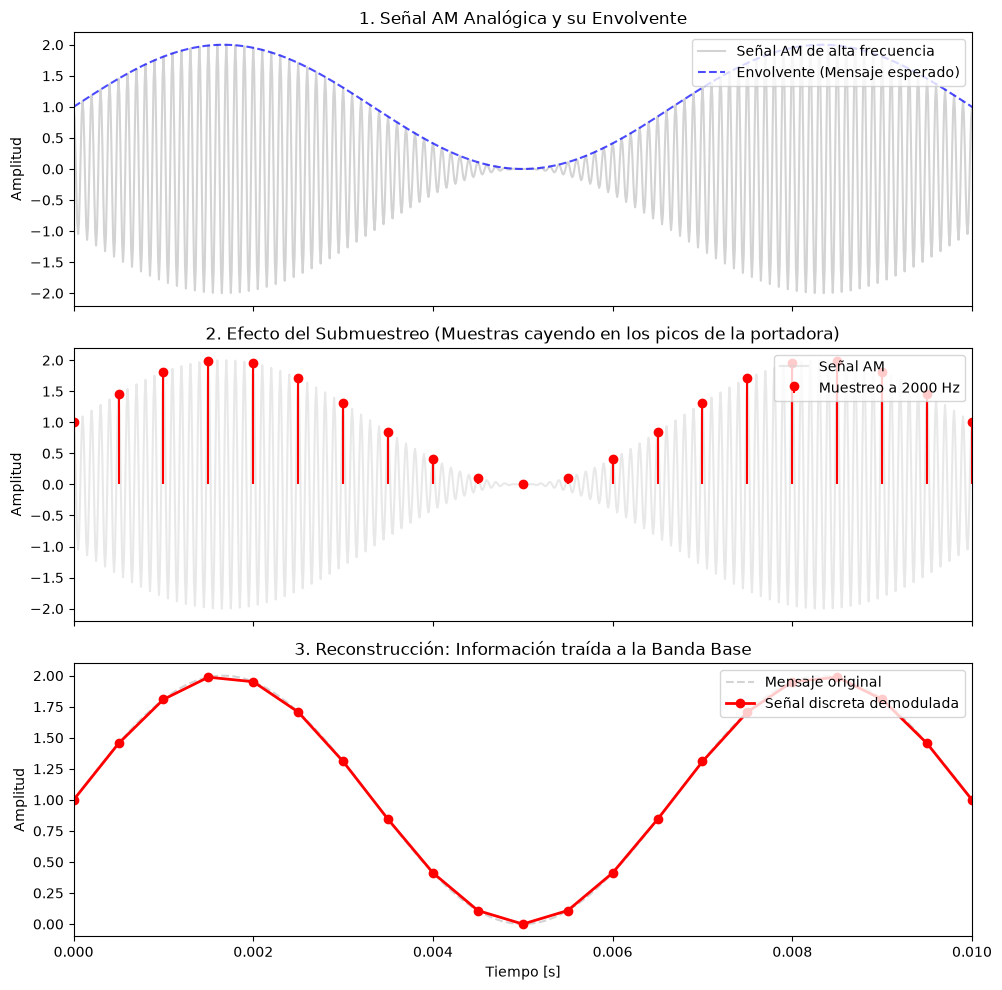

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parámetros de la señal
fm = 150         # Frecuencia de la señal de información (Hz)
fc = 10000       # Frecuencia de la portadora (Hz)
fs_alta = 100000 # Frecuencia de muestreo muy alta para simular un espectro "continuo"
t = np.arange(0, 1, 1/fs_alta)

# 2. Señal original y modulación AM
mensaje = np.sin(2 * np.pi * fm * t)
portadora = np.cos(2 * np.pi * fc * t)
senial_am = (1 + mensaje) * portadora  # AM con 100% de índice de modulación

# 3. Demodulación por submuestreo
# Condición 1: fs_sub >= 2*fm (Nyquist del mensaje: fs_sub >= 300 Hz)
# Condición 2: fc = k * fs_sub (10000 Hz = 5 * 2000 Hz). Elegimos fs_sub = 2000 Hz.
fs_sub = 2000
paso = int(fs_alta / fs_sub)

# Extraemos solo las muestras que coinciden con la nueva frecuencia
t_sub = t[::paso]
senial_am_sub = senial_am[::paso]

# 4. Visualización del efecto
fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Gráfico 1: La señal modulada y la envolvente
axs[0].plot(t, senial_am, color='lightgray', label='Señal AM de alta frecuencia')
axs[0].plot(t, 1 + mensaje, color='blue', linestyle='--', alpha=0.7, label='Envolvente (Mensaje esperado)')
axs[0].set_title('1. Señal AM Analógica y su Envolvente')
axs[0].set_ylabel('Amplitud')
axs[0].legend(loc='upper right')
axs[0].set_xlim(0, 0.01)  # Zoom en los primeros 10 ms para ver la forma de onda

# Gráfico 2: El momento del muestreo (Magia visual)
axs[1].plot(t, senial_am, color='lightgray', alpha=0.5, label='Señal AM')
axs[1].stem(t_sub, senial_am_sub, linefmt='red', markerfmt='ro', basefmt=' ', 
            label=f'Muestreo a {fs_sub} Hz')
axs[1].set_title('2. Efecto del Submuestreo (Muestras cayendo en los picos de la portadora)')
axs[1].set_ylabel('Amplitud')
axs[1].legend(loc='upper right')
axs[1].set_xlim(0, 0.01)  # Zoom en los primeros 10 ms para ver la forma de onda

# Gráfico 3: La información recuperada en banda base
axs[2].plot(t, 1 + mensaje, color='lightgray', linestyle='--', label='Mensaje original')
axs[2].plot(t_sub, senial_am_sub, color='red', marker='o', linestyle='-', linewidth=2, 
            label='Señal discreta demodulada')
axs[2].set_title('3. Reconstrucción: Información traída a la Banda Base')
axs[2].set_xlabel('Tiempo [s]')
axs[2].set_ylabel('Amplitud')
axs[2].legend(loc='upper right')
axs[2].set_xlim(0, 0.01)  # Zoom en los primeros 10 ms para ver la forma de onda

plt.tight_layout()
plt.show()

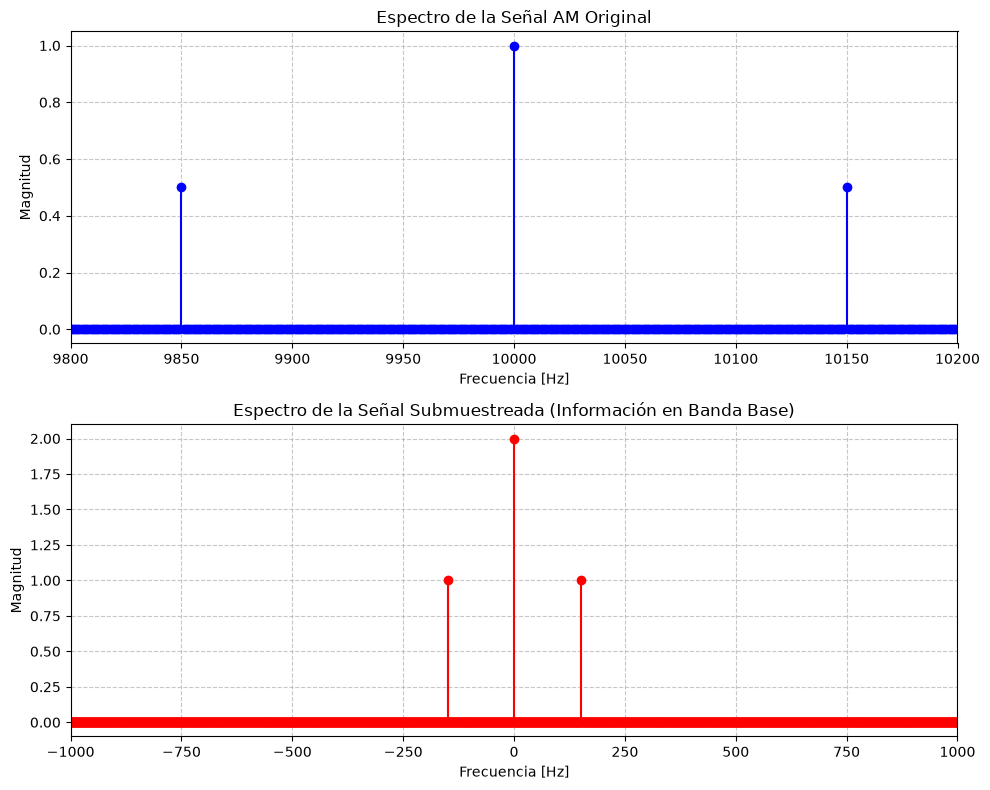

In [30]:
# Cálculo de la FFT para la señal AM original (alta frecuencia)
N_alta = len(senial_am)
# np.fft.fftfreq genera el eje de frecuencias; tomamos solo la mitad positiva
frecuencias_am = np.fft.fftfreq(N_alta, 1/fs_alta)[:N_alta//2]
# Normalizamos la magnitud del espectro
espectro_am = np.abs(np.fft.fft(senial_am))[:N_alta//2] * (2.0 / N_alta)

# Cálculo de la FFT para la señal submuestreada (reconstruida)
N_sub = len(senial_am_sub)
frecuencias_sub = np.fft.fftfreq(N_sub, 1/fs_sub)
espectro_sub = np.abs(np.fft.fft(senial_am_sub)) * (2.0 / N_sub)

# Creación de los gráficos de espectro
fig, axs = plt.subplots(2, 1, figsize=(10, 8))

# Gráfico 1: Espectro de la AM inicial
axs[0].stem(frecuencias_am, espectro_am, linefmt='blue', markerfmt='bo', basefmt=' ')
axs[0].set_title('Espectro de la Señal AM Original')
axs[0].set_xlabel('Frecuencia [Hz]')
axs[0].set_ylabel('Magnitud')
# Hacemos zoom alrededor de la portadora (ej. de 0 a 150 Hz) para ver bien los picos
axs[0].set_xlim(9800, 10200) # Zoom alrededor de la portadora 
axs[0].grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Espectro de la señal reconstruida
axs[1].stem(frecuencias_sub, espectro_sub, linefmt='red', markerfmt='ro', basefmt=' ')
axs[1].set_title('Espectro de la Señal Submuestreada (Información en Banda Base)')
axs[1].set_xlabel('Frecuencia [Hz]')
axs[1].set_ylabel('Magnitud')
# Mostramos hasta la frecuencia de Nyquist del submuestreo
axs[1].set_xlim(-fs_sub/2, fs_sub/2) 
axs[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()